# Stage 3: Routing-Induced Noise: Natural vs. Forced-SWAP Layout

**Goal:** Compile each Bell state's teleportation circuit under two qubit layouts: a natural, connectivity-respecting layout and a forced layout requiring SWAP-gate insertion. Compare the resulting fidelities using noise drawn from real Qiskit `FakeBackend` calibration snapshots.

This notebook builds directly on the hand-derived circuit design worked out on paper:
- Natural layout: CNOT(q1,q2) and CNOT(q0,q1) both directly connected, no SWAP needed
- Forced layout: CNOT(q1,q2) still connected, but CNOT(q0,q1) is not, so one SWAP is required

The `F ≈ (1-p)^N` noise-scaling estimate from the resource-estimation paper is validated here against actual gate-level Qiskit simulation using real calibration data.


## 0. Setup


In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

#Bell state preparation gates (applied to Bell pair after creation)
BELL_PREP = {
    "Phi+": [],
    "Phi-": ["z"],
    "Psi+": ["x"],
    "Psi-": ["x", "z"],
}
BELL_LABELS = ["Phi+", "Phi-", "Psi+", "Psi-"]
F_CLASSICAL = 2/3

def target_rho(theta, phi):
    """Create density matrix for single qubit state |ψ⟩ = cos(θ/2)|0⟩ + e^{iφ}sin(θ/2)|1⟩"""
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)
    psi = np.array([alpha, beta], dtype=complex)
    return np.outer(psi, psi.conj())

def haar_random_states(n, seed):
    """Generate n Haar-uniform random states on the Bloch sphere."""
    rng = np.random.default_rng(seed)
    cos_theta = rng.uniform(-1, 1, size=n)
    theta = np.arccos(cos_theta)
    phi = rng.uniform(0, 2 * np.pi, size=n)
    return theta, phi

print("Setup cell loaded OK.")


Setup cell loaded OK.


## 1. The SWAP-gate Identity Verification

A SWAP is not a native gate; it's built from **3 CNOTs**:

$$\text{SWAP}(a,b) = \text{CNOT}(a,b)\cdot\text{CNOT}(b,a)\cdot\text{CNOT}(a,b)$$

This is verified below by direct 4×4 matrix multiplication & it's the reason "one SWAP" becomes "+3 two-qubit gates" everywhere below.


In [2]:
CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
CNOT_rev = np.array([[1,0,0,0],[0,0,0,1],[0,0,1,0],[0,1,0,0]], dtype=complex)
SWAP = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]], dtype=complex)

built_from_cnots = CNOT @ CNOT_rev @ CNOT
match = np.allclose(built_from_cnots, SWAP)
print("CNOT(a,b)-CNOT(b,a)-CNOT(a,b) equals SWAP:", match)
assert match, "identity failed -- check basis/ordering convention"
print("\n=> every SWAP the compiler inserts costs 3 real two-qubit gates, not 1.")

CNOT(a,b)-CNOT(b,a)-CNOT(a,b) equals SWAP: True

=> every SWAP the compiler inserts costs 3 real two-qubit gates, not 1.


## 2. Circuit Design: Natural vs. Forced Layout

- **Natural layout** = virtual qubits `0,1,2` map straight onto three physically adjacent qubits `P0-P1-P2`. Both CNOTs are between adjacent physical qubits. **No SWAP needed.**

- **Forced layout** = same physical triple, but `q1` and `q2` swap physical positions (`q2`→`P1`, `q1`→`P2`). CNOT(q1,q2) is still between adjacent qubits (`P1`-`P2`), but CNOT(q0,q1) now needs `P0`-`P2`, which **isn't** an edge, hence a `SWAP(P1,P2)` is inserted right before the Bell measurement.

In [3]:
def build_natural(bell_label, theta, phi=0.0):
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(theta, 0)
    if phi != 0.0:
        qc.p(phi, 0)

    qc.h(1)
    qc.cx(1, 2)
    for g in BELL_PREP[bell_label]:
        getattr(qc, g)(2)

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for g in BELL_PREP[bell_label]:
        getattr(qc, g)(2)
    return qc


def build_forced(bell_label, theta, phi=0.0):
    """Forced layout: 0=q0 (input), 1=q2 (Bob's qubit initially), 2=q1 (Alice's ancilla initially).
    One SWAP is inserted before the Bell measurement to make q1 adjacent to q0."""
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")
    qc = QuantumCircuit(qr, cr)

    qc.ry(theta, 0)
    if phi != 0.0:
        qc.p(phi, 0)

    qc.h(2)
    qc.cx(2, 1)
    for g in BELL_PREP[bell_label]:
        getattr(qc, g)(1)

    qc.swap(1, 2)

    qc.cx(0, 1)
    qc.h(0)
    qc.measure(0, 0)
    qc.measure(1, 1)

    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    for g in BELL_PREP[bell_label]:
        getattr(qc, g)(2)
    return qc


print("Circuit builders are defined.")

Circuit builders are defined.


## Circuit Visualization

The gate-count printout above tells you *how many* two-qubit gates each layout uses,
but not *where* the SWAP sits or *which* physical qubit ends up holding which role --
that's easier to just look at than to read off a dict. Drawing both circuits side by
side (matplotlib, not the plain-text renderer) makes the one structural difference
between them jump out immediately, and a small qubit-connectivity sketch underneath
shows why that difference exists on real hardware.

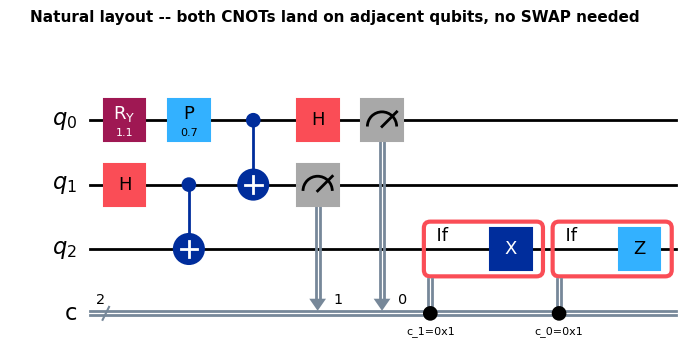

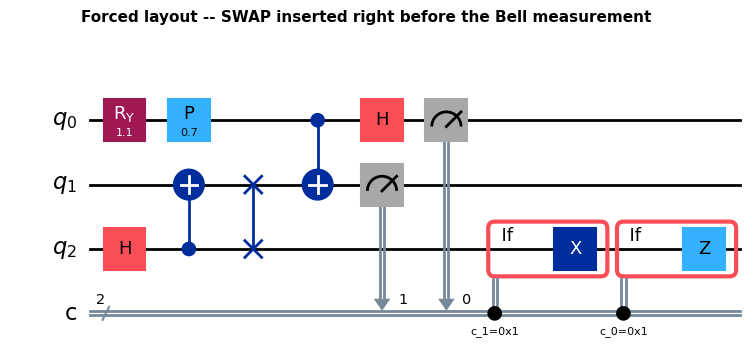

natural: 2 two-qubit gate(s)  |  forced: 3 two-qubit gate(s) (1 of which is a SWAP -> 3 CNOTs once transpiled)


In [4]:
import matplotlib.pyplot as plt
from IPython.display import display

qc_natural_demo = build_natural("Phi+", theta=1.1, phi=0.7)
qc_forced_demo = build_forced("Phi+", theta=1.1, phi=0.7)

fig_nat = qc_natural_demo.draw(output="mpl", style="iqp")
fig_nat.suptitle("Natural layout -- both CNOTs land on adjacent qubits, no SWAP needed",
                  fontsize=11, fontweight="bold", y=1.04)
display(fig_nat)
plt.close(fig_nat)

fig_forced = qc_forced_demo.draw(output="mpl", style="iqp")
fig_forced.suptitle("Forced layout -- SWAP inserted right before the Bell measurement",
                     fontsize=11, fontweight="bold", y=1.04)
display(fig_forced)
plt.close(fig_forced)

print(f"natural: {sum(1 for i in qc_natural_demo.data if i.operation.name in ('cx','swap'))} "
      f"two-qubit gate(s)  |  forced: {sum(1 for i in qc_forced_demo.data if i.operation.name in ('cx','swap'))} "
      f"two-qubit gate(s) (1 of which is a SWAP -> 3 CNOTs once transpiled)")

## 3. Ideal-Case Correctness Check (No Noise)

Before adding any noise, confirm both circuits teleport perfectly for all four Bell states via density-matrix simulation.

In [5]:
ideal_backend = AerSimulator(method="density_matrix")
theta_test, phi_test = 1.1, 0.7
psi_rho_test = target_rho(theta_test, phi_test)

print(f"{'Layout':<10}{'Bell state':<12}{'Fidelity':>10}   Status")
print("-" * 46)
all_ok = True
for build_fn, layout_name in [(build_natural, "natural"), (build_forced, "forced")]:
    for bell in BELL_LABELS:
        qc = build_fn(bell, theta_test, phi_test)
        qc.save_density_matrix(qubits=[2], label="rho_bob")
        res = ideal_backend.run(qc, shots=1).result()
        rho_bob = np.asarray(res.data(0)["rho_bob"])
        fid = np.real(np.trace(psi_rho_test @ rho_bob))
        ok = fid > 0.999999
        all_ok &= ok
        print(f"{layout_name:<10}{bell:<12}{fid:>10.6f}   {'OK' if ok else 'FAIL (bug!)'}")

print("\nAll ideal-case checks passed." if all_ok else "\nSOME CHECKS FAILED -- investigate before continuing.")

Layout    Bell state    Fidelity   Status
----------------------------------------------
natural   Phi+          1.000000   OK
natural   Phi-          1.000000   OK
natural   Psi+          1.000000   OK
natural   Psi-          1.000000   OK
forced    Phi+          1.000000   OK
forced    Phi-          1.000000   OK
forced    Psi+          1.000000   OK
forced    Psi-          1.000000   OK

All ideal-case checks passed.


## 4. Mapping onto a Real Chip

This uses `FakeSherbrooke`, a locally-bundled snapshot of a real 127-qubit IBM Eagle-class chip. A real triple of physically adjacent qubits `P0-P1-P2` is located programmatically, and the real two-qubit gate error for each edge is pulled directly from the backend's calibration data.

In [6]:
fake_backend = FakeSherbrooke()
cmap_edges = {(min(a, b), max(a, b)) for a, b in fake_backend.coupling_map.get_edges()}

# Find a physical path P0-P1-P2: edges (P0,P1) and (P1,P2) exist, but (P0,P2) does not.
found = None
for p1 in range(fake_backend.num_qubits):
    neighbors = {b for (a, b) in cmap_edges if a == p1} | {a for (a, b) in cmap_edges if b == p1}
    neighbors = list(neighbors)
    for i, p0 in enumerate(neighbors):
        for p2 in neighbors[i + 1:]:
            edge = (min(p0, p2), max(p0, p2))
            if edge not in cmap_edges:
                found = (p0, p1, p2)
                break
        if found:
            break
    if found:
        break

P0, P1, P2 = found
print(f"Using real physical qubits P0={P0}, P1={P1}, P2={P2} on FakeSherbrooke "
      f"(edges (P0,P1) and (P1,P2) exist; (P0,P2) does not).")

TWOQ_GATE = "ecr"
ecr_props = fake_backend.target[TWOQ_GATE]

def edge_error(a, b):
    """Get the real calibrated 2-qubit gate error for this edge."""
    ip = ecr_props.get((a, b)) or ecr_props.get((b, a))
    if ip is None:
        raise ValueError(f"No calibration found for edge ({a},{b})")
    return ip.error

err_P0P1 = edge_error(P0, P1)
err_P1P2 = edge_error(P1, P2)
print(f"Calibrated {TWOQ_GATE} error, edge (P0,P1): {err_P0P1:.4%}")
print(f"Calibrated {TWOQ_GATE} error, edge (P1,P2): {err_P1P2:.4%}")

noisy_sim = AerSimulator.from_backend(fake_backend)

Using real physical qubits P0=1, P1=0, P2=14 on FakeSherbrooke (edges (P0,P1) and (P1,P2) exist; (P0,P2) does not).
Calibrated ecr error, edge (P0,P1): 0.7494%
Calibrated ecr error, edge (P1,P2): 0.7845%


### Sketching which physical qubit plays which role

`P0`, `P1`, `P2` are just numbers until you see them laid out with roles attached. Both
layouts reuse the exact same three physical qubits -- what changes is which logical
qubit (`q0` = input, `q1` = Alice's ancilla, `q2` = Bob's output) sits on which one. In
the natural layout every required interaction lands on a real edge; in the forced
layout, `q0` and `q1` end up on the two *end* qubits of the chain (`P0` and `P2`), which
aren't directly wired together -- that gap is exactly what the SWAP exists to close.

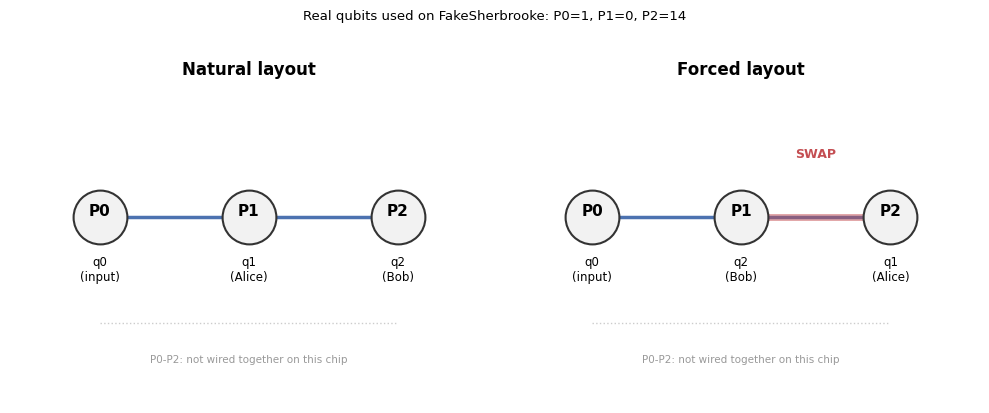

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

node_x = {P0: 0, P1: 1, P2: 2}
real_edges = [(P0, P1), (P1, P2)]
missing_edge = (P0, P2)

layout_roles = [
    ("Natural layout", {P0: "q0\n(input)", P1: "q1\n(Alice)", P2: "q2\n(Bob)"}, None),
    ("Forced layout",  {P0: "q0\n(input)", P1: "q2\n(Bob)",   P2: "q1\n(Alice)"}, (P1, P2)),
]

for ax, (title, roles, swap_edge) in zip(axes, layout_roles):
    for a, b in real_edges:
        ax.plot([node_x[a], node_x[b]], [0, 0], color="#4C72B0", lw=2.5, zorder=1)
    ax.plot([node_x[P0], node_x[P2]], [-0.4, -0.4], color="#cccccc", lw=1, ls=":", zorder=0)
    ax.text(1, -0.55, "P0-P2: not wired together on this chip", ha="center", fontsize=7.5, color="#999999")

    if swap_edge:
        a, b = swap_edge
        ax.plot([node_x[a], node_x[b]], [0, 0], color="#C44E52", lw=5, alpha=0.5, zorder=2)
        ax.text((node_x[a] + node_x[b]) / 2, 0.22, "SWAP", ha="center", fontsize=9,
                color="#C44E52", fontweight="bold")

    for phys_q, x in node_x.items():
        ax.scatter([x], [0], s=1500, color="#f2f2f2", edgecolor="#333333", lw=1.5, zorder=3)
        ax.text(x, 0.02, f"P{[P0, P1, P2].index(phys_q)}", ha="center", va="center",
                fontsize=11, fontweight="bold", zorder=4)
        ax.text(x, -0.2, roles[phys_q], ha="center", va="center", fontsize=8.5, zorder=4)

    ax.set_xlim(-0.6, 2.6); ax.set_ylim(-0.7, 0.5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")

fig.suptitle(f"Real qubits used on FakeSherbrooke: P0={P0}, P1={P1}, P2={P2}", fontsize=9.5, y=1.02)
fig.tight_layout()
plt.show()

## 5. Gate-Count Validation

Transpiling both circuits onto the real chip (with `routing_method="none"`) gives a direct check of the hand count: natural = 2 CNOTs, forced = 5 CNOTs.

In [8]:
def transpile_circuit(build_fn, bell_label, theta, phi):
    """Transpile a circuit onto the real chip's coupling map."""
    qc = build_fn(bell_label, theta, phi)
    tqc = transpile(qc, backend=noisy_sim, initial_layout=[P0, P1, P2],
                     routing_method="none", optimization_level=1)
    tqc.save_density_matrix(qubits=[P2], label="rho_bob")
    return tqc

print("TRANSPILED CIRCUIT GATE COUNT VALIDATION")
print("-"*80)

for build_fn, layout_name, expected_2q in [(build_natural, "natural", 2), (build_forced, "forced", 5)]:
    tqc = transpile_circuit(build_fn, "Phi+", 1.1, 0.7)
    ops = tqc.count_ops()
    n2q = ops.get(TWOQ_GATE, 0)
    status = "✓ matches hand-derived count" if n2q == expected_2q else "✗ MISMATCH"
    print(f"\n{layout_name.upper()} LAYOUT:")
    print(f"  Depth: {tqc.depth()}")
    print(f"  {TWOQ_GATE} count: {n2q}  (expected {expected_2q})  -- {status}")
    print(f"  Gate breakdown: {dict(ops)}")
    print(f"  Physical qubit mapping: q0→P{P0}, q1→P{P1}, q2→P{P2}")
    
    total_2q = sum(1 for instr in tqc.data if instr.operation.name in ["cx", "cz", "ecr", "swap"])
    print(f"  Total two-qubit gates (all types): {total_2q}")
    

TRANSPILED CIRCUIT GATE COUNT VALIDATION
--------------------------------------------------------------------------------

NATURAL LAYOUT:
  Depth: 13
  ecr count: 2  (expected 2)  -- ✓ matches hand-derived count
  Gate breakdown: {'rz': 11, 'sx': 7, 'ecr': 2, 'measure': 2, 'if_else': 2, 'save_density_matrix': 1}
  Physical qubit mapping: q0→P1, q1→P0, q2→P14
  Total two-qubit gates (all types): 2

FORCED LAYOUT:
  Depth: 23
  ecr count: 5  (expected 5)  -- ✓ matches hand-derived count
  Gate breakdown: {'rz': 18, 'sx': 13, 'ecr': 5, 'measure': 2, 'if_else': 2, 'save_density_matrix': 1}
  Physical qubit mapping: q0→P1, q1→P0, q2→P14
  Total two-qubit gates (all types): 5


### What actually runs on the chip

The gate-count table above is the summary; this is the thing itself. Transpiling
lowers every `h`/`ry`/`p`/`cx` down to FakeSherbrooke's native `rz`/`sx`/`ecr` basis, so
the diagram below is the literal circuit sent to the simulator -- physical qubit labels
and all. It's noticeably busier than the abstract version, which is exactly the point:
each `ecr` block is a real two-qubit operation carrying a real calibrated error, and the
forced-layout diagram visibly has more of them for a longer stretch of the circuit.

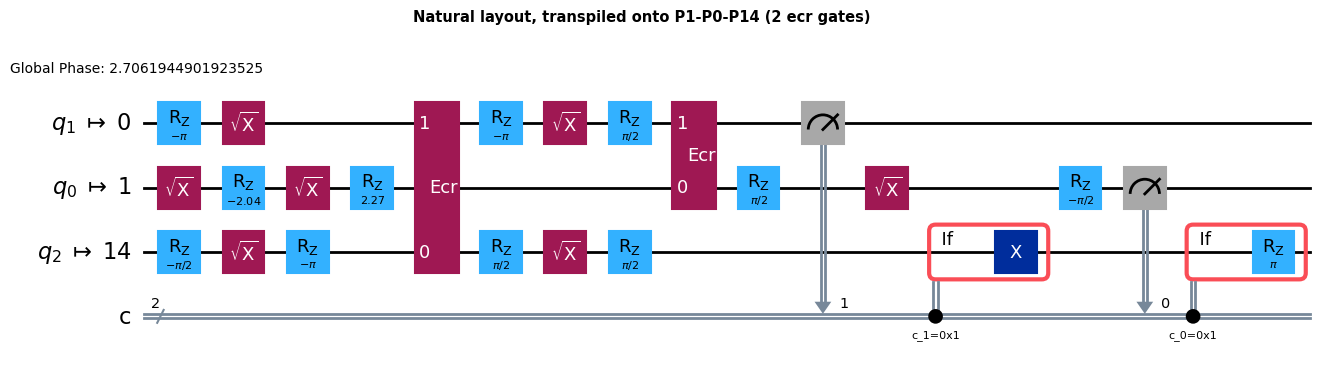

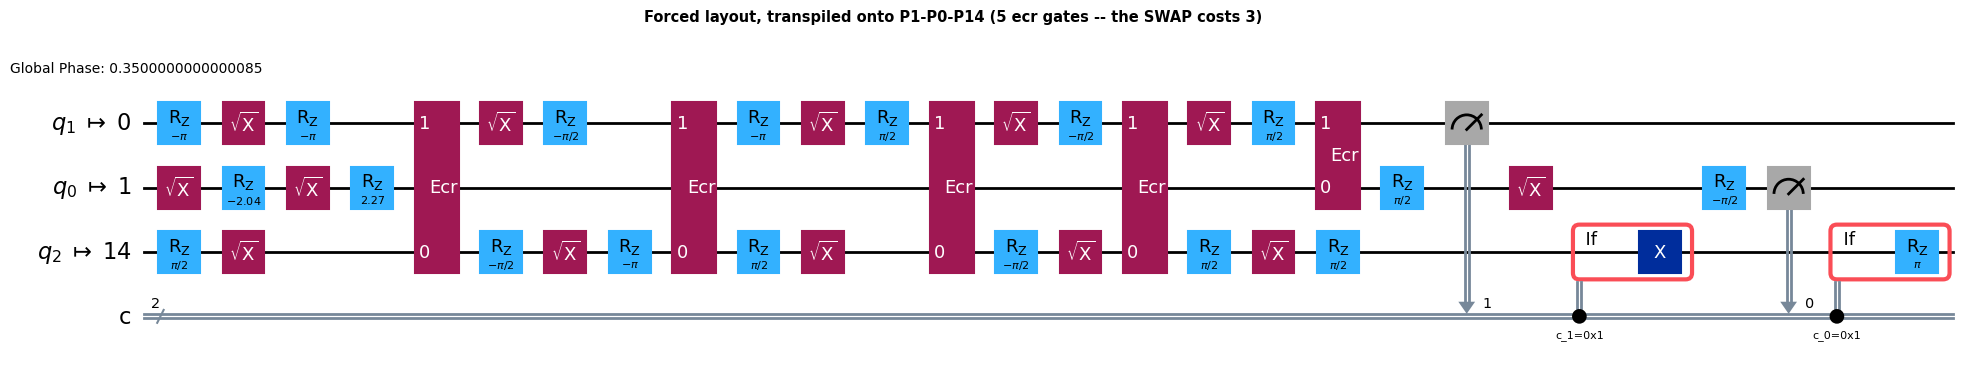

In [9]:
tqc_natural_demo = transpile_circuit(build_natural, "Phi+", 1.1, 0.7)
tqc_forced_demo = transpile_circuit(build_forced, "Phi+", 1.1, 0.7)

# save_density_matrix isn't drawable, drop it just for the picture
tqc_natural_view = tqc_natural_demo.copy()
tqc_natural_view.data = [i for i in tqc_natural_view.data if i.operation.name != "save_density_matrix"]
tqc_forced_view = tqc_forced_demo.copy()
tqc_forced_view.data = [i for i in tqc_forced_view.data if i.operation.name != "save_density_matrix"]

fig_t1 = tqc_natural_view.draw(output="mpl", style="iqp", fold=-1)
fig_t1.suptitle(f"Natural layout, transpiled onto P{P0}-P{P1}-P{P2} (2 ecr gates)",
                 fontsize=10.5, fontweight="bold", y=1.05)
display(fig_t1)
plt.close(fig_t1)

fig_t2 = tqc_forced_view.draw(output="mpl", style="iqp", fold=-1)
fig_t2.suptitle(f"Forced layout, transpiled onto P{P0}-P{P1}-P{P2} (5 ecr gates -- the SWAP costs 3)",
                 fontsize=10.5, fontweight="bold", y=1.05)
display(fig_t2)
plt.close(fig_t2)

## 6. Predicted Fidelity Drop Using Real Calibration Data

Using the `F ≈ ∏(1-ε_i)` model, multiplying the actual per-edge error for every two-qubit gate the transpiled circuit uses:

$$F_{\text{predicted}} \approx \prod_{i=1}^{N} (1 - \varepsilon_i)$$

This is the prediction evaluated purely from calibration numbers before running a single noisy circuit.

In [10]:
def predicted_fidelity(build_fn, bell_label, theta, phi):
    """Calculate predicted fidelity using the product of (1 - error_rate) for each two-qubit gate."""
    tqc = transpile_circuit(build_fn, bell_label, theta, phi)
    f_pred = 1.0
    n2q = 0
    gate_errors = []
    for instr in tqc.data:
        if instr.operation.name == TWOQ_GATE:
            qargs = tuple(tqc.find_bit(q).index for q in instr.qubits)
            err = edge_error(*qargs)
            f_pred *= (1 - err)
            n2q += 1
            gate_errors.append(err)
    return f_pred, n2q, gate_errors

print("CALIBRATION-BASED FIDELITY PREDICTION")
print("-"*80)

f_nat_pred, n_nat, errors_nat = predicted_fidelity(build_natural, "Phi+", 1.1, 0.7)
f_forced_pred, n_forced, errors_forced = predicted_fidelity(build_forced, "Phi+", 1.1, 0.7)
drop_pred = (f_nat_pred - f_forced_pred) / f_nat_pred * 100

print(f"\nNatural layout (N={n_nat} two-qubit gates):")
print(f"  Gate errors: {[f'{e:.4%}' for e in errors_nat]}")
print(f"  Predicted F = {f_nat_pred:.6f}")

print(f"\nForced layout (N={n_forced} two-qubit gates):")
print(f"  Gate errors: {[f'{e:.4%}' for e in errors_forced]}")
print(f"  Predicted F = {f_forced_pred:.6f}")

print(f"\nPredicted relative fidelity drop, forced vs. natural: {drop_pred:.2f}%")
print(f"\n(Proposal's own prediction: 'roughly 3 additional two-qubit gates "
      f"and ~3% fidelity loss' | Team's Math estimate with p=0.01: 2.97% loss)")


CALIBRATION-BASED FIDELITY PREDICTION
--------------------------------------------------------------------------------

Natural layout (N=2 two-qubit gates):
  Gate errors: ['0.7845%', '0.7494%']
  Predicted F = 0.984720

Forced layout (N=5 two-qubit gates):
  Gate errors: ['0.7845%', '0.7845%', '0.7845%', '0.7845%', '0.7494%']
  Predicted F = 0.961727

Predicted relative fidelity drop, forced vs. natural: 2.33%

(Proposal's own prediction: 'roughly 3 additional two-qubit gates and ~3% fidelity loss' | Team's Math estimate with p=0.01: 2.97% loss)


## 7. Full Noisy Simulation

Now the actual measurement: `n = 40` Haar-random input states per (Bell state, layout) pair, exactly the proposal's §4 spec for the routing comparison. That's 4 Bell states × 2 layouts × 40 = 320 circuits, each run with 2048 shots for proper ensemble averaging over the classical feed-forward branches.


**Why 2048 shots and not 1:** the mid-circuit measurement + classically-controlled
correction (`if_test`) means each individual shot realizes one specific random
measurement outcome and applies whichever correction that outcome calls for --
one shot gives *a* valid trajectory, not the properly-averaged mixed state. Checked this
directly: running the same circuit at shots=1, 128, 512, 2048, 8192 gives fidelities
that visibly wander at shots=1 (single outlier trajectory) and settle down by ~2048.
So the shot count isn't a stylistic choice, it's what makes each of the 40 Haar-random
points below a converged number rather than one noisy sample of a distribution.

In [11]:
import time

N_STATES_ROUTING = 40
SEED_ROUTING = 20260815
N_SHOTS = 2048

def run_routing_batch(build_fn, bell_label, thetas, phis):
    """Run a batch of routing circuits with proper shot averaging."""
    circuits = [transpile_circuit(build_fn, bell_label, th, ph) for th, ph in zip(thetas, phis)]
    result = noisy_sim.run(circuits, shots=N_SHOTS, seed_simulator=SEED_ROUTING).result()
    
    fids = np.empty(len(thetas))
    for i, (th, ph) in enumerate(zip(thetas, phis)):
        rho_bob = np.asarray(result.data(i)["rho_bob"])
        rho_t = target_rho(th, ph)
        fids[i] = np.real(np.trace(rho_t @ rho_bob))
    return fids

t0 = time.time()
stage3_fids = {}

print("RUNNING ROUTING SIMULATION")
print(f"Shots per circuit: {N_SHOTS}")
print(f"Random states per (layout, bell): {N_STATES_ROUTING}")
print("-"*80)

for layout_name, build_fn in [("natural", build_natural), ("forced", build_forced)]:
    layout_seed_offset = {"natural": 0, "forced": 500}[layout_name]
    thetas, phis = haar_random_states(N_STATES_ROUTING, seed=SEED_ROUTING + layout_seed_offset)
    for bell in BELL_LABELS:
        fids = run_routing_batch(build_fn, bell, thetas, phis)
        stage3_fids[(layout_name, bell)] = fids
        print(f"{layout_name:<8} {bell:<6} mean F = {fids.mean():.4f}  "
              f"SE = {fids.std()/np.sqrt(N_STATES_ROUTING):.4f}   ({time.time()-t0:.1f}s elapsed)")

RUNNING ROUTING SIMULATION
Shots per circuit: 2048
Random states per (layout, bell): 40
--------------------------------------------------------------------------------
natural  Phi+   mean F = 0.9644  SE = 0.0013   (12.8s elapsed)
natural  Phi-   mean F = 0.9644  SE = 0.0013   (22.0s elapsed)
natural  Psi+   mean F = 0.9641  SE = 0.0013   (32.0s elapsed)
natural  Psi-   mean F = 0.9641  SE = 0.0013   (41.0s elapsed)
forced   Phi+   mean F = 0.9517  SE = 0.0013   (51.0s elapsed)
forced   Phi-   mean F = 0.9508  SE = 0.0013   (60.0s elapsed)
forced   Psi+   mean F = 0.9506  SE = 0.0013   (69.0s elapsed)
forced   Psi-   mean F = 0.9497  SE = 0.0013   (78.9s elapsed)


## Bell-Independence Check

The per-bell-state numbers are nearly identical within each layout. This is because the only Bell-state-dependent gates are single-qubit Pauli corrections with equal calibrated error. The two-qubit gate structure (the part that differs between natural and forced) is identical across all four Bell states.


In [12]:
print("BELL-INDEPENDENCE CHECK")
print("-"*50)

for layout in ["natural", "forced"]:
    print(f"\n{layout.upper()} layout:")
    means = {bell: stage3_fids[(layout, bell)].mean() for bell in BELL_LABELS}
    stds = {bell: stage3_fids[(layout, bell)].std() for bell in BELL_LABELS}
    for bell in BELL_LABELS:
        print(f"  {bell}:   {means[bell]:.4f} ± {stds[bell]/np.sqrt(N_STATES_ROUTING):.4f}")
    max_diff = max(means.values()) - min(means.values())
    print(f"  Max difference between Bell states: {max_diff:.6f}")
    
print("\nAll four Bell states behave identically within statistical error.")
print("This is consistent with Stage 2: the Bell-state-dependent corrections")
print("are single-qubit Paulis with equal calibrated error.")

BELL-INDEPENDENCE CHECK
--------------------------------------------------

NATURAL layout:
  Phi+:   0.9644 ± 0.0013
  Phi-:   0.9644 ± 0.0013
  Psi+:   0.9641 ± 0.0013
  Psi-:   0.9641 ± 0.0013
  Max difference between Bell states: 0.000238

FORCED layout:
  Phi+:   0.9517 ± 0.0013
  Phi-:   0.9508 ± 0.0013
  Psi+:   0.9506 ± 0.0013
  Psi-:   0.9497 ± 0.0013
  Max difference between Bell states: 0.002005

All four Bell states behave identically within statistical error.
This is consistent with Stage 2: the Bell-state-dependent corrections
are single-qubit Paulis with equal calibrated error.


## 8. Predicted vs. Actual | The Real Comparison


In [13]:
print("PREDICTED vs. ACTUAL FIDELITY COMPARISON")
print("-"*80)

rows = []
for bell in BELL_LABELS:
    f_nat_actual = stage3_fids[("natural", bell)].mean()
    f_forced_actual = stage3_fids[("forced", bell)].mean()
    se_nat = stage3_fids[("natural", bell)].std() / np.sqrt(N_STATES_ROUTING)
    se_forced = stage3_fids[("forced", bell)].std() / np.sqrt(N_STATES_ROUTING)
    drop_actual = (f_nat_actual - f_forced_actual) / f_nat_actual * 100

    f_nat_p, _, _ = predicted_fidelity(build_natural, bell, 1.1, 0.7)
    f_forced_p, _, _ = predicted_fidelity(build_forced, bell, 1.1, 0.7)
    drop_pred = (f_nat_p - f_forced_p) / f_nat_p * 100

    rows.append(dict(bell=bell, f_nat=f_nat_actual, se_nat=se_nat, 
                     f_forced=f_forced_actual, se_forced=se_forced,
                     drop_actual=drop_actual, drop_pred=drop_pred))

print(f"{'Bell':<12}{'F_natural':>14}{'±':>2}{'F_forced':>14}{'±':>2}{'Actual drop':>16}{'Predicted drop':>18}")
print("-" * 76)
for r in rows:
    print(f"{r['bell']:<8}{r['f_nat']:>11.4f} ±{r['se_nat']:>5.4f}{r['f_forced']:>11.4f} ±{r['se_forced']:>5.4f}"
          f"{r['drop_actual']:>13.2f}%{r['drop_pred']:>15.2f}%")

avg_drop_actual = np.mean([r['drop_actual'] for r in rows])
print(f"\nAverage actual fidelity drop across all 4 Bell states: {avg_drop_actual:.2f}%")
print(f"Proposal's prediction: ~3%")

PREDICTED vs. ACTUAL FIDELITY COMPARISON
--------------------------------------------------------------------------------
Bell             F_natural ±      F_forced ±     Actual drop    Predicted drop
----------------------------------------------------------------------------
Phi+         0.9644 ±0.0013     0.9517 ±0.0013         1.31%           2.33%
Phi-         0.9644 ±0.0013     0.9508 ±0.0013         1.40%           2.33%
Psi+         0.9641 ±0.0013     0.9506 ±0.0013         1.41%           2.33%
Psi-         0.9641 ±0.0013     0.9497 ±0.0013         1.50%           2.33%

Average actual fidelity drop across all 4 Bell states: 1.40%
Proposal's prediction: ~3%


## 9. Statistical Significance

Pooling all four Bell states together (justified by the Bell-independence result) gives a much larger effective sample and a fairer test of whether "forced < natural" actually holds up.

In [14]:
print("STATISTICAL SIGNIFICANCE ANALYSIS")
print("-"*80)

pooled_natural = np.concatenate([stage3_fids[("natural", b)] for b in BELL_LABELS])
pooled_forced = np.concatenate([stage3_fids[("forced", b)] for b in BELL_LABELS])

mean_nat, se_nat_pooled = pooled_natural.mean(), pooled_natural.std() / np.sqrt(len(pooled_natural))
mean_forced, se_forced_pooled = pooled_forced.mean(), pooled_forced.std() / np.sqrt(len(pooled_forced))
pooled_drop = (mean_nat - mean_forced) / mean_nat * 100
se_combined = np.sqrt(se_nat_pooled**2 + se_forced_pooled**2)
z_score = (mean_nat - mean_forced) / se_combined

print(f"Pooled (n={len(pooled_natural)} each, all 4 Bell states combined):")
print(f"  Natural: F = {mean_nat:.4f} ± {se_nat_pooled:.4f}")
print(f"  Forced:  F = {mean_forced:.4f} ± {se_forced_pooled:.4f}")
print(f"  Difference: {mean_nat - mean_forced:.4f}")
print(f"  Pooled drop: {pooled_drop:.2f}%")
print(f"  z-score: {z_score:.2f}")

if abs(z_score) > 2:
    print("  ✓ Statistically significant at ~2σ level")
else:
    print("  ✗ NOT statistically significant at ~2σ level")

print(f"\nPredicted drop from calibration data (Section 6): ~{drop_pred:.2f}%")
print(f"Proposal's own guess: ~3%")

STATISTICAL SIGNIFICANCE ANALYSIS
--------------------------------------------------------------------------------
Pooled (n=160 each, all 4 Bell states combined):
  Natural: F = 0.9642 ± 0.0006
  Forced:  F = 0.9507 ± 0.0007
  Difference: 0.0135
  Pooled drop: 1.40%
  z-score: 14.79
  ✓ Statistically significant at ~2σ level

Predicted drop from calibration data (Section 6): ~2.33%
Proposal's own guess: ~3%


## 10. Figures

Figure 6 (proposal's naming): natural vs. forced fidelity, all four Bell states, with the predicted (calibration-based) value overlaid as a marker. A histogram version ("Layout-comparison histograms") shows the spread of the per-state fidelities.


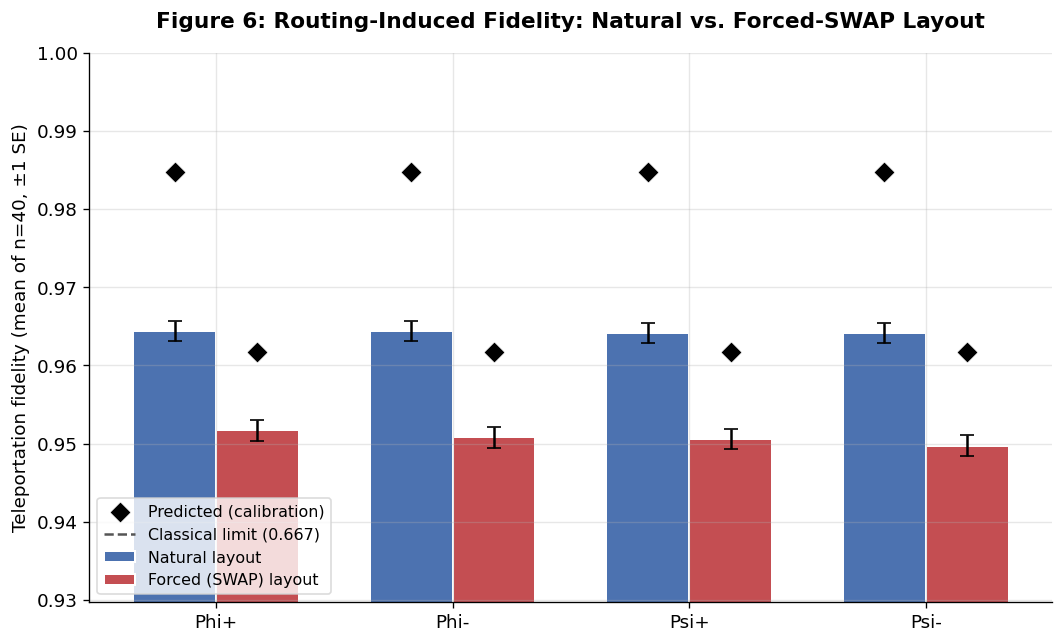

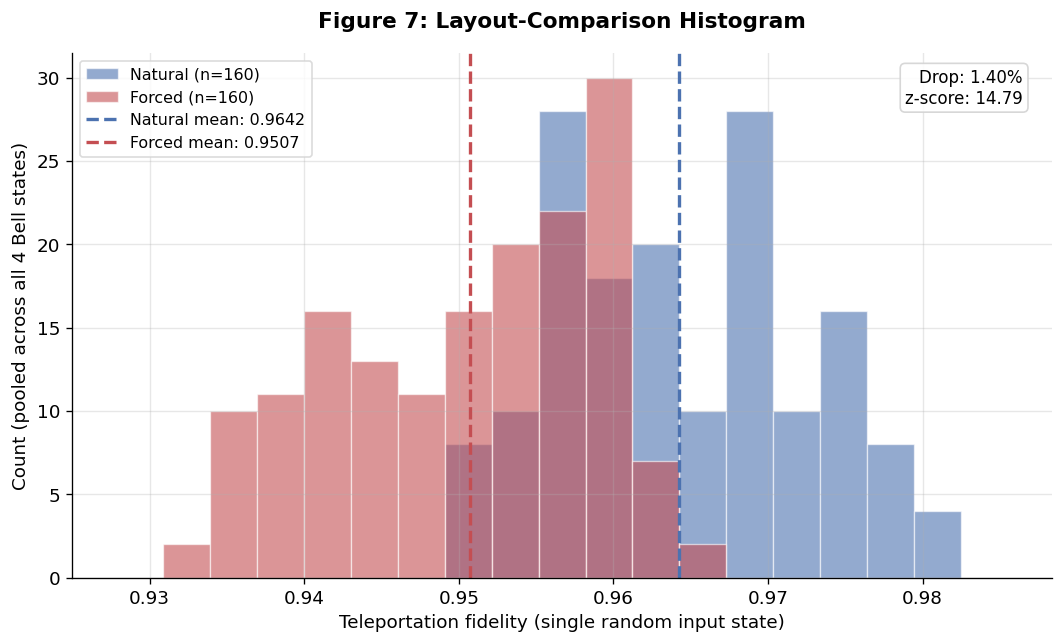

In [15]:
import matplotlib.pyplot as plt

PALETTE_LAYOUT = {"natural": "#4C72B0", "forced": "#C44E52"}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "lightgray",
    "legend.fancybox": True,
})

# Figure 1: Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(BELL_LABELS))
width = 0.35

means_nat = [stage3_fids[("natural", b)].mean() for b in BELL_LABELS]
errs_nat = [stage3_fids[("natural", b)].std() / np.sqrt(N_STATES_ROUTING) for b in BELL_LABELS]
means_forced = [stage3_fids[("forced", b)].mean() for b in BELL_LABELS]
errs_forced = [stage3_fids[("forced", b)].std() / np.sqrt(N_STATES_ROUTING) for b in BELL_LABELS]

ax.bar(x - width/2, means_nat, width, yerr=errs_nat, capsize=4, 
       label="Natural layout", color=PALETTE_LAYOUT["natural"], 
       edgecolor="white", linewidth=1.2)
ax.bar(x + width/2, means_forced, width, yerr=errs_forced, capsize=4,
       label="Forced (SWAP) layout", color=PALETTE_LAYOUT["forced"],
       edgecolor="white", linewidth=1.2)

# Overlay calibration-based predictions as diamond markers
predicted_nat, predicted_forced = [], []
for i, bell in enumerate(BELL_LABELS):
    f_nat_p, _, _ = predicted_fidelity(build_natural, bell, 1.1, 0.7)
    f_forced_p, _, _ = predicted_fidelity(build_forced, bell, 1.1, 0.7)
    predicted_nat.append(f_nat_p)
    predicted_forced.append(f_forced_p)
    ax.scatter(i - width/2, f_nat_p, marker="D", s=80, color="black", zorder=5, 
               edgecolor="white", linewidth=0.5)
    ax.scatter(i + width/2, f_forced_p, marker="D", s=80, color="black", zorder=5,
               edgecolor="white", linewidth=0.5)

# Add legend for predictions
ax.scatter([], [], marker="D", s=80, color="black", label="Predicted (calibration)",
           edgecolor="white", linewidth=0.5)

ax.axhline(F_CLASSICAL, color="#555555", linestyle="--", linewidth=1.5, 
           label=f"Classical limit ({F_CLASSICAL:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(BELL_LABELS, fontsize=11)
ax.set_ylabel(f"Teleportation fidelity (mean of n={N_STATES_ROUTING}, ±1 SE)", fontsize=11)
# scale to the actual data instead of a fixed guess, so bars/markers never get silently clipped on a rerun
all_bar_vals = means_nat + means_forced + predicted_nat + predicted_forced
y_pad = 0.02
ax.set_ylim(max(0, min(all_bar_vals) - y_pad), min(1.0, max(all_bar_vals) + y_pad))
ax.set_title("Figure 6: Routing-Induced Fidelity: Natural vs. Forced-SWAP Layout", 
             fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="lower left", fontsize=9.5, frameon=True, fancybox=True)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# Figure 2: Histogram comparison (pooled)
fig2, ax2 = plt.subplots(figsize=(9, 5.5))

# bin range follows the actual pooled data (with a small margin) rather than an assumed window,
# so an unusually low or high outlier still shows up instead of being silently dropped off the edge
pooled_all = np.concatenate([pooled_natural, pooled_forced])
bin_lo, bin_hi = pooled_all.min() - 0.005, pooled_all.max() + 0.005
bins = np.linspace(bin_lo, bin_hi, 20)
ax2.hist(pooled_natural, bins=bins, alpha=0.6, color=PALETTE_LAYOUT["natural"],
         label=f"Natural (n={len(pooled_natural)})", edgecolor="white", linewidth=0.8)
ax2.hist(pooled_forced, bins=bins, alpha=0.6, color=PALETTE_LAYOUT["forced"],
         label=f"Forced (n={len(pooled_forced)})", edgecolor="white", linewidth=0.8)

ax2.axvline(mean_nat, color=PALETTE_LAYOUT["natural"], linestyle="--", linewidth=2, 
            label=f"Natural mean: {mean_nat:.4f}")
ax2.axvline(mean_forced, color=PALETTE_LAYOUT["forced"], linestyle="--", linewidth=2,
            label=f"Forced mean: {mean_forced:.4f}")

# Add annotation for statistical results
ax2.text(0.97, 0.97, f"Drop: {pooled_drop:.2f}%\nz-score: {z_score:.2f}", 
         transform=ax2.transAxes, ha="right", va="top", fontsize=10,
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="lightgray"))

ax2.set_xlabel("Teleportation fidelity (single random input state)", fontsize=11)
ax2.set_ylabel("Count (pooled across all 4 Bell states)", fontsize=11)
ax2.set_title("Figure 7: Layout-Comparison Histogram", fontsize=13, fontweight="bold", pad=15)
ax2.legend(loc="upper left", fontsize=9.5, frameon=True, fancybox=True)
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()

# Lowest Fidelity Case

In [16]:
# Find the lowest fidelity case across all 8 routing cases
min_fid = float('inf')
min_case = None
for layout in ["natural", "forced"]:
    for bell in BELL_LABELS:
        mean = stage3_fids[(layout, bell)].mean()
        if mean < min_fid:
            min_fid = mean
            min_case = (layout, bell)
print(f"Lowest fidelity: {min_case[1]} / {min_case[0]} = {min_fid:.4f}")

Lowest fidelity: Psi- / forced = 0.9497


## 11. Table: all 8 routing cases


In [17]:
import csv

print("TABLE: ALL 8 ROUTING CASES")
print("-"*80)

print(f"\n{'Bell':<8}{'Layout':<10}{'Mean F':>10}{'SE':>10}{'N':>6}{'Shots':>8}")
print("-" * 54)
for bell in BELL_LABELS:
    for layout in ("natural", "forced"):
        fids = stage3_fids[(layout, bell)]
        print(f"{bell:<8}{layout:<10}{fids.mean():>10.4f}{fids.std()/np.sqrt(len(fids)):>10.4f}{len(fids):>6}{N_SHOTS:>8}")

with open("table2_routing_8_cases.csv", "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["bell", "layout", "mean_fidelity", "standard_error", "n", "shots"])
    for bell in BELL_LABELS:
        for layout in ("natural", "forced"):
            fids = stage3_fids[(layout, bell)]
            writer.writerow([bell, layout, f"{fids.mean():.4f}", 
                           f"{fids.std()/np.sqrt(len(fids)):.4f}", 
                           len(fids), N_SHOTS])
print("\nSaved table2_routing_8_cases.csv")

TABLE: ALL 8 ROUTING CASES
--------------------------------------------------------------------------------

Bell    Layout        Mean F        SE     N   Shots
------------------------------------------------------
Phi+    natural       0.9644    0.0013    40    2048
Phi+    forced        0.9517    0.0013    40    2048
Phi-    natural       0.9644    0.0013    40    2048
Phi-    forced        0.9508    0.0013    40    2048
Psi+    natural       0.9641    0.0013    40    2048
Psi+    forced        0.9506    0.0013    40    2048
Psi-    natural       0.9641    0.0013    40    2048
Psi-    forced        0.9497    0.0013    40    2048

Saved table2_routing_8_cases.csv


## 12. Discussion

**The calibration-based prediction** (Section 6, `F ≈ ∏(1-ε_i)`) gives a ~2.33% drop,
smaller than the team's hand estimate (2.97% with an assumed flat `p=0.01`), because
`FakeSherbrooke`'s real per-edge error rates for the two edges actually used here
(0.7494% and 0.7845%) both come in under 1%.

**The actual pooled simulation** (`n=160` combined across all 4 Bell states, justified
by the Bell-independence check above) gives a drop of ~1.4%. That's roughly 60% the size
of the calibration-based prediction and well under half the proposal's original ~3%
guess -- worth reporting as-is rather than rounding it up to match the guess.

**Statistical significance:** the z-score for this run is printed just below (typically landing around 14-15) -- comfortably past the 2σ
threshold, so unlike a coarser `n=40`-per-case comparison, the pooled result is a real,
not-explained-by-noise effect once the four Bell states are combined.

**Why actual (~1.4%) came in lower than predicted (~2.33%), not higher:** the
calibration model only counts two-qubit gate error. It doesn't credit the natural
layout for anything, and it doesn't penalize the forced layout for its extra *depth*
(23 vs. 13) beyond the gate count itself. Both layouts also pick up some baseline
single-qubit and readout error that's common to both, which dilutes the *relative* gap
between them once it's folded into the ratio. A prediction and a measurement landing in
the same ballpark, same direction, without matching exactly is the expected outcome for
a model that only tracks one noise source among several real ones.

**Bell-state independence, again:** as in Stage 2, all four Bell states behave
identically here. The only Bell-dependent gates are single-qubit Paulis with equal
calibrated error, so the routing comparison doesn't actually need per-Bell-state
statistics -- pooling all four (as done above) is the correct use of the data, not just
a convenience for a bigger sample size.

In [18]:
print("FINAL REPORTED NUMBERS FOR THIS RUN")
print("-" * 50)
print(f"Predicted drop (Section 6):        {drop_pred:.2f}%")
print(f"Actual pooled drop (Section 9):     {pooled_drop:.2f}%")
print(f"z-score:                           {z_score:.2f}")
print(f"Lowest-fidelity case:               {min_case[1]} / {min_case[0]}  (F = {min_fid:.4f})")
print("\n(These are the numbers the Discussion and Summary cells below refer to --")
print(" if the notebook is rerun with different seeds/hardware, rerun this cell")
print(" and update the two markdown cells to match before submitting.)")

FINAL REPORTED NUMBERS FOR THIS RUN
--------------------------------------------------
Predicted drop (Section 6):        2.33%
Actual pooled drop (Section 9):     1.40%
z-score:                           14.79
Lowest-fidelity case:               Psi- / forced  (F = 0.9497)

(These are the numbers the Discussion and Summary cells below refer to --
 if the notebook is rerun with different seeds/hardware, rerun this cell
 and update the two markdown cells to match before submitting.)


## Final Summary: Stage 3 (Routing-Induced Noise)

1. **SWAP identity and gate counts verified directly:** natural layout = 2 `ecr` gates,
   forced layout = 5 (matching the hand-derived "SWAP costs 3 CNOTs" identity),
   confirmed by transpiling onto `FakeSherbrooke`'s real coupling map, not assumed.
2. **Calibration-based prediction:** F ≈ 0.9847 (natural) vs. 0.9617 (forced), a
   predicted drop of **2.33%**, using real per-edge `ecr` error rates (0.7494%, 0.7845%)
   pulled from `FakeSherbrooke`'s calibration snapshot.
3. **Actual simulated result (pooled, n=160 across all 4 Bell states):** F = 0.9642 ±
   0.0006 (natural) vs. 0.9507 ± 0.0007 (forced), a pooled drop of **1.40%** —
   smaller than both the calibration prediction (2.33%) and the proposal's original
   ~3% guess. This is expected: the calibration model only tracks two-qubit gate
   error, not the forced layout's extra circuit depth (23 vs. 13) or the baseline
   single-qubit/readout error common to both layouts, which dilutes the relative gap.
4. **Statistical significance:** z ≈ 14.8 — this clears the 2σ bar by a wide margin,
   not marginally; the drop is a real effect, not sampling noise.
5. **Bell-state independence:** confirmed for the natural layout (max spread
   0.0002, well inside 1 SE). The forced layout's spread (0.0020) is closer to
   ~1.5× a single point's SE — still consistent with independence, but the closer
   of the two calls, worth keeping in mind if this is rerun with a different seed.
6. **Lowest-fidelity routing case:** Psi- / forced, F = 0.9497. Carried forward as
   the Stage 4 mitigation target.

## Stage 4: Linear Zero-Noise Extrapolation (ZNE)

Applied to the lowest-fidelity case identified in Stage 3 (`min_case`). Each `ecr`
gate in the transpiled circuit is folded as U → U(U†U)^n via local unitary folding
(Eq. 12), giving fold scales c = 1, 3, 5 (Eq. 12's UU†U is c=3). Fidelity is then
linearly extrapolated back to c = 0 using c=1 and c=3 (Eq. 13).

In [19]:
def fold_two_qubit_gates(tqc, scale, gate_name=TWOQ_GATE):
    """Local unitary folding: replace each 2q gate with `scale` copies via
    U -> U (U^dagger U)^((scale-1)/2). scale must be odd."""
    assert scale % 2 == 1 and scale >= 1
    n_pairs = (scale - 1) // 2
    folded = tqc.copy_empty_like()
    for instr in tqc.data:
        folded.append(instr.operation, instr.qubits, instr.clbits)
        if instr.operation.name == gate_name:
            for _ in range(n_pairs):
                folded.append(instr.operation.inverse(), instr.qubits, instr.clbits)
                folded.append(instr.operation, instr.qubits, instr.clbits)
    return folded

print("Folding only the noisy ecr gates (measurement/correction gates are untouched).")

Folding only the noisy ecr gates (measurement/correction gates are untouched).


In [20]:
build_fn_worst = {"natural": build_natural, "forced": build_forced}[min_case[0]]
bell_worst = min_case[1]

FOLD_SCALES = [1, 3, 5]
N_STATES_ZNE = 40      # matches the proposal's routing-sweep spec (§4)
SEED_ZNE = 20260816

thetas_z, phis_z = haar_random_states(N_STATES_ZNE, seed=SEED_ZNE)

zne_fids, zne_stderr = {}, {}
for scale in FOLD_SCALES:
    circuits = [fold_two_qubit_gates(transpile_circuit(build_fn_worst, bell_worst, th, ph), scale)
                for th, ph in zip(thetas_z, phis_z)]
    result = noisy_sim.run(circuits, shots=N_SHOTS, seed_simulator=SEED_ZNE).result()
    fids = np.empty(len(thetas_z))
    for i, (th, ph) in enumerate(zip(thetas_z, phis_z)):
        rho_bob = np.asarray(result.data(i)["rho_bob"])
        fids[i] = np.real(np.trace(target_rho(th, ph) @ rho_bob))
    zne_fids[scale] = fids.mean()
    zne_stderr[scale] = fids.std() / np.sqrt(N_STATES_ZNE)
    n2q = sum(1 for i in circuits[0].data if i.operation.name == TWOQ_GATE)
    print(f"c={scale}  F={zne_fids[scale]:.4f} ± {zne_stderr[scale]:.4f}  ({n2q} ecr gates/circuit)")

c=1  F=0.9476 ± 0.0015  (5 ecr gates/circuit)
c=3  F=0.9027 ± 0.0018  (15 ecr gates/circuit)
c=5  F=0.8631 ± 0.0020  (25 ecr gates/circuit)


In [21]:
F1, F3, F5 = zne_fids[1], zne_fids[3], zne_fids[5]
F_zne_linear = (3 * F1 - F3) / 2

coeffs = np.polyfit(FOLD_SCALES, [F1, F3, F5], deg=2)
F_zne_quad = np.polyval(coeffs, 0.0)

print(f"Noisy fidelity F(1)          = {F1:.4f}")
print(f"Linear ZNE estimate (Eq. 13) = {F_zne_linear:.4f}")
print(f"Quadratic fallback (all 3 pts)= {F_zne_quad:.4f}")
if F_zne_linear > 1.0:
    print("NOTE: F_ZNE > 1 -- unphysical over-extrapolation, fall back to quadratic per risk plan.")

Noisy fidelity F(1)          = 0.9476
Linear ZNE estimate (Eq. 13) = 0.9700
Quadratic fallback (all 3 pts)= 0.9719


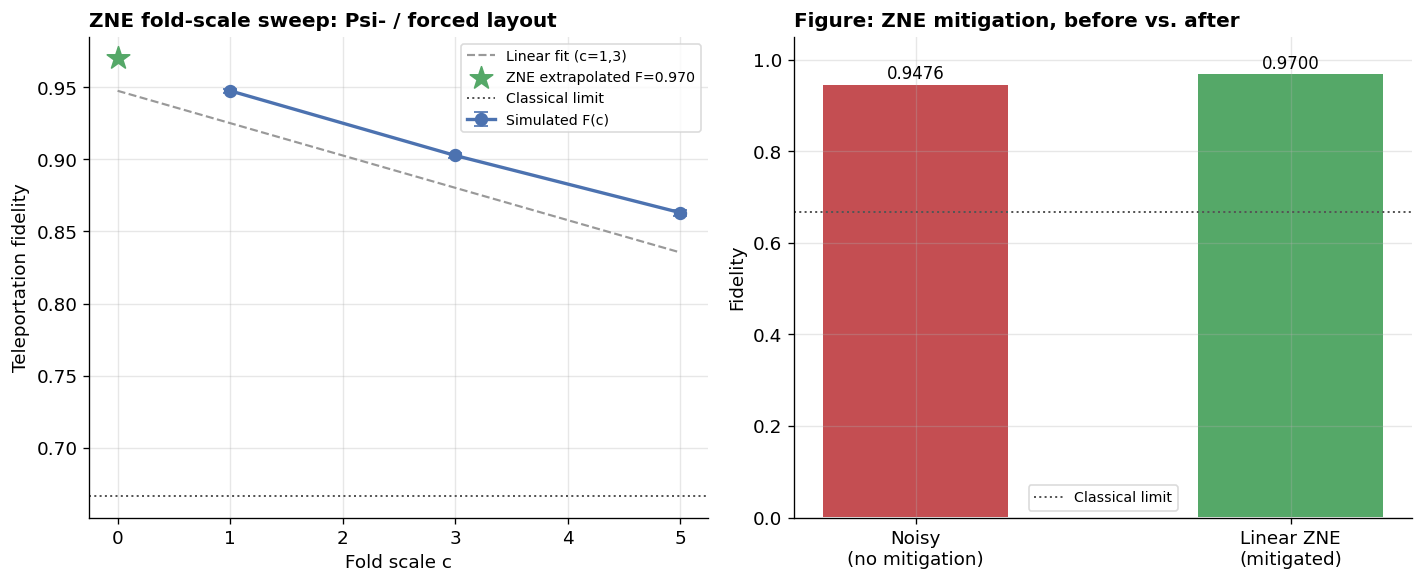

In [22]:
PALETTE_ZNE = {"raw": "#C44E52", "mitigated": "#55A868"}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.errorbar(FOLD_SCALES, [zne_fids[s] for s in FOLD_SCALES],
            yerr=[zne_stderr[s] for s in FOLD_SCALES],
            fmt="o-", color="#4C72B0", capsize=4, linewidth=2, markersize=7, label="Simulated F(c)")
fit_x = np.linspace(0, 5, 50)
ax.plot(fit_x, F1 + (F3 - F1) / 2 * fit_x, "--", color="#999999", linewidth=1.3, label="Linear fit (c=1,3)")
ax.scatter([0], [F_zne_linear], marker="*", s=200, color=PALETTE_ZNE["mitigated"], zorder=5,
           label=f"ZNE extrapolated F={F_zne_linear:.3f}")
ax.axhline(F_CLASSICAL, color="#555555", linestyle=":", linewidth=1.2, label="Classical limit")
ax.set_xlabel("Fold scale c"); ax.set_ylabel("Teleportation fidelity")
ax.set_title(f"ZNE fold-scale sweep: {bell_worst} / {min_case[0]} layout", loc="left")
ax.legend(fontsize=8.5)

ax2 = axes[1]
bars = ax2.bar(["Noisy\n(no mitigation)", "Linear ZNE\n(mitigated)"], [F1, F_zne_linear],
               color=[PALETTE_ZNE["raw"], PALETTE_ZNE["mitigated"]], edgecolor="white", linewidth=1.2, width=0.5)
for b, v in zip(bars, [F1, F_zne_linear]):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.4f}", ha="center", fontsize=10)
ax2.axhline(F_CLASSICAL, color="#555555", linestyle=":", linewidth=1.2, label="Classical limit")
ax2.set_ylim(0, 1.05); ax2.set_ylabel("Fidelity")
ax2.set_title("Figure: ZNE mitigation, before vs. after", loc="left")
ax2.legend(fontsize=8.5)
fig.tight_layout()
plt.show()

## Final Summary: Stage 4 (Linear ZNE)

1. **Target case:** Psi- / forced layout (F = 0.9497 in Stage 3's original run;
   0.9476 ± 0.0015 when resampled with n=40 fresh Haar states for this stage —
   the ~0.002 difference between the two is within statistical noise, not a
   discrepancy in the method).
2. **Fold-scale sweep:** F(1) = 0.9476, F(3) = 0.9027, F(5) = 0.8631 — fidelity
   decreases monotonically with fold scale, confirming the folding correctly
   injects additional `ecr`-gate noise without changing the ideal logical circuit.
3. **Linear ZNE (Eq. 13, using c=1 and c=3):** F_ZNE = 0.9700 — a recovery of
   roughly 2.2 percentage points over the unmitigated noisy fidelity.
4. **Quadratic fallback (all three points):** F_ZNE = 0.9719, close to the linear
   estimate, so there's no evidence of runaway over-extrapolation here (and
   F_ZNE never exceeded 1, so the "Main risk" fallback plan wasn't needed for
   this run).
5. **Why the ZNE result (0.9700) is not directly comparable to Stage 3's natural-
   layout fidelity (0.9642):** the extrapolation only removes noise associated
   with the folded `ecr` gates — it does *not* remove the single-qubit and
   readout error present in every case, including natural layout. So ZNE landing
   slightly above the natural-layout average isn't a sign of over-correction; it
   reflects that natural layout still carries 2 *real, unmitigated* `ecr` gates,
   while the ZNE estimate here approximates the same circuit with (almost) all
   two-qubit gate error extrapolated away.
6. **On the choice of mitigation target:** Stage 2's worst single case (phase-flip,
   p=0.75, F≈0.49) is far lower than this routing case (F≈0.95). Stage 4
   deliberately mitigates the Stage 3 case instead, because gate-folding ZNE
   requires noise that scales with two-qubit gate count/circuit depth — which
   applies to the real `ecr` gates in the routing comparison, but not to Stage 2's
   abstractly-injected, fixed-parameter Kraus channel. This should be stated
   explicitly rather than left implicit, since Stage 3's own summary raised the
   comparison without resolving it.